In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

## 1. 데이터 불러오기

In [2]:
mercari_df = pd.read_csv('../data/mercari_train.tsv', sep='\t')
mercari_df.shape

(1482535, 8)

## 2. 기본 탐색

In [3]:
mercari_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [4]:
mercari_df.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [5]:
mercari_df.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


In [6]:
mercari_df.isnull().sum()
# category_name, brand_name, item_description에 결측치 존재 -> 아래에서 'Other_Null'로 채움

train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64

## 3. 가격 분포 확인 및 0원 데이터 체크

price는 오른쪽으로 치우친 분포일 것으로 예상되고, 0원인 행(증정품/입력 오류 추정)이 섞여 있을 수 있음.
분포를 먼저 눈으로 확인하고, 이후 0원 데이터를 제거.

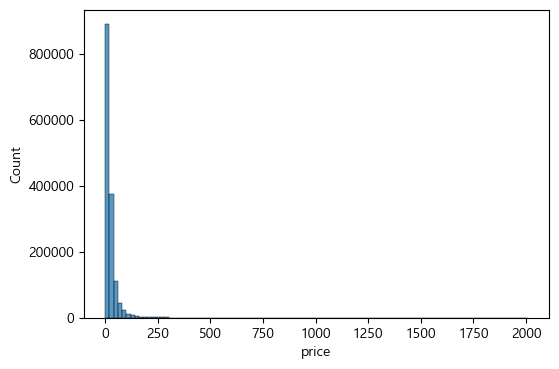

price
0.0         874
3.0       18703
4.0       16139
5.0       31502
5.5          33
          ...  
1999.0        1
2000.0        6
2004.0        1
2006.0        1
2009.0        1
Name: count, Length: 828, dtype: int64

In [7]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프에 한글이 깨지지 않도록 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

y_labels = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_labels, bins=100)
plt.show()

mercari_df.value_counts('price').sort_index()
# y_labels 0처리 이후 다시 재조정예정

## 4. price==0/2000달러 이상 행 삭제 / train_id 컬럼 제거 / 중복 제거

- price가 0인 행은 대회 목표(가격 제안)와 무관한 노이즈로 보고 제거
- price가 2000달러 이상인 행은 극단적 이상치로 보고 제거 (전체 분포 대비 매우 소수이며, 모델이 이런 극단값에 끌려가는 것을 방지)
- train_id는 식별자일 뿐 가격과 무관하므로 제거
- 완전히 동일한 행(중복 등록 등)은 학습에 불필요하므로 제거

In [8]:
# 전처리전 체크
print(f'전처리 전 : {mercari_df.shape}')

# 가격이 0인 데이터 제거
mercari_df = mercari_df[mercari_df['price']>0]
print(f'0 제거 후 : {mercari_df.shape}')

# 가격이 2000달러 이상인 이상치 데이터 제거
mercari_df = mercari_df[mercari_df['price']<2000]
print(f'2000달러 이상 제거 후 : {mercari_df.shape}')

# train_id 컬럼 제거
mercari_df.drop(columns='train_id', inplace=True)
mercari_df = mercari_df.drop_duplicates()
mercari_df = mercari_df.reset_index(drop=True)

print(f'train_id 제거 후 : {mercari_df.shape}')

전처리 전 : (1482535, 8)
0 제거 후 : (1481661, 8)


2000달러 이상 제거 후 : (1481652, 8)


train_id 제거 후 : (1481603, 7)


## 5. 결측치 처리 (Other_Null)

`brand_name`, `category_name`, `item_description`의 결측치를 `'Other_Null'`이라는 별도 카테고리 문자열로 채움.
단순 삭제 대신 이렇게 채우면 "브랜드/카테고리/설명이 없다"는 정보 자체를 모델이 활용할 수 있음.

In [9]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna('Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna('Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna('Other_Null')

mercari_df.isnull().sum()

name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
dtype: int64

## 6. 카테고리 3단계 분할

`category_name`은 `/`로 구분된 대분류/중분류/소분류 계층 구조(예: `Men/Tops/T-shirts`)임.
이를 `cat_dae`(대분류), `cat_jung`(중분류), `cat_so`(소분류) 3개 컬럼으로 분리.
`/`가 없는 경우(위에서 채운 `Other_Null` 등)는 3개 컬럼 모두 `Other_Null` 처리.

In [10]:
def split_cat(category_name):
    try:
        cat_dae, cat_jung, cat_so = category_name.split('/')[:3]
        return cat_dae, cat_jung, cat_so
    except ValueError:
        return 'Other_Null', 'Other_Null', 'Other_Null'

mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = zip(
    *mercari_df['category_name'].apply(lambda x: split_cat(x))
)

print('대분류 개수:', mercari_df['cat_dae'].nunique())
print('중분류 개수:', mercari_df['cat_jung'].nunique())
print('소분류 개수:', mercari_df['cat_so'].nunique())
mercari_df[['category_name', 'cat_dae', 'cat_jung', 'cat_so']].head()

대분류 개수: 11
중분류 개수: 114


소분류 개수: 871


,category_name,cat_dae,cat_jung,cat_so
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces


## 7. price 로그 변환 (log1p)

타깃이 오른쪽으로 치우친 분포이므로 `np.log1p`로 정규분포에 가까운 형태로 변환.
평가지표(RMSLE) 자체가 로그 스케일 오차를 재는 지표이므로, 타깃을 미리 log1p로 바꿔두면
이후 일반 회귀모델의 RMSE 최소화가 곧 RMSLE 최소화가 됨.

`mercari_df['price']`를 log1p 값으로 덮어쓰므로, 이후 셀부터 `price` 컬럼은 로그 스케일임에 유의.
(X_features를 만들 때 price/price 계열 컬럼은 타깃이므로 반드시 제외)

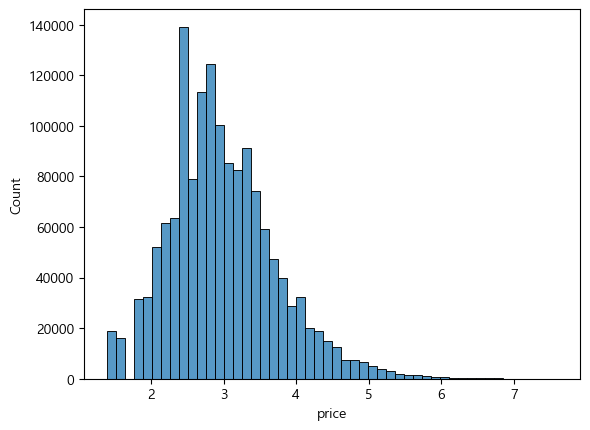

In [11]:
import numpy as np

y_labels = mercari_df['price']

mercari_df['price']= np.log1p(y_labels)
y_labels = np.log1p(y_labels)

sns.histplot(y_labels, bins=50)
plt.show()

## 8. `item_description` 텍스트 클렌징 및 토큰화

`name`, `brand_name`, `cat_dae/jung/so`는 이후 벡터화 단계에서 `CountVectorizer`/`TfidfVectorizer`/
원-핫 인코딩의 기본 설정에 맡기고, `item_description`(긴 설명글)만 별도로 정제함:

1. 소문자화 + 영문자/공백 외 문자 제거 + 중복 공백 정리
2. 단어 단위 토큰화(`word_tokenize`)
3. 불용어 제거(단, `no/not/nor/never` 등 부정 표현은 의미가 크므로 불용어에서 제외)

행 수(약 148만 건)가 많아 토큰화 셀 실행에 다소 시간이 걸릴 수 있음.

In [12]:
# nltk 리소스 준비 (최초 1회만 다운로드, 이미 있으면 스킵)
import nltk

for resource, path in [('punkt_tab', 'tokenizers/punkt_tab'), ('stopwords', 'corpora/stopwords')]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(resource, quiet=True)

In [13]:
# 'decription'만 텍스트 전처리(나머지는 알아서!)
# 모듈 불러오기
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter

#텍스트 클리닝(소문자/공백)
def text_cleaning(text):

    # 소문자로 변환
    text = text.lower()

    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 제거하면 안 되는 부정 표현
negative_words = {
    'no',
    'not',
    'nor',
    'never'
}

# 불용어 목록에서 부정 표현 제외
stop_words = stop_words - negative_words


#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 함수

def preprocess_text(text):
     # 1. 소문자 / 영문자 / 공백 정리
    text = text_cleaning(text)

    # 2. 단어 단위 토큰화
    tokens = word_tokenize(text)

    # 3. 불용어 제거
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return tokens

In [14]:
#소문자 / 영문자/공백/여러개공백 처리 / 토크나이즈 적용
mercari_df['item_description'] = mercari_df['item_description'].apply(preprocess_text)

# 클렌징 및 토큰화 후, 최종 확인
mercari_df['item_description'].head()

0                               [no, description, yet]
1    [keyboard, great, condition, works, like, came...
2    [adorable, top, hint, lace, key, hole, back, p...
3    [new, tags, leather, horses, retail, rm, stand...
4                [complete, certificate, authenticity]
Name: item_description, dtype: object

## 8-1. 결측치(Other_Null) 페널티 피처 생성

`brand_name`, `category_name`, `item_description`을 `Other_Null`로 채웠던 정보를 원-핫/텍스트 벡터의
암묵적인 신호로만 남겨두지 않고, "이 상품이 결측 정보를 몇 개나 갖고 있는가"를 별도의 수치형 피처로 명시적으로 만듦.
브랜드/카테고리/설명이 없을수록 가격이 낮게 형성되는 경향이 있어, 결측 개수 자체가 가격에 대한 페널티 신호로 쓰일 수 있음.

In [15]:
NULL_PENALTY_COLS = ['brand_name', 'category_name', 'item_description']

def null_penalty(df, cols=NULL_PENALTY_COLS):
    """Other_Null로 채워졌던 컬럼 개수(0~3)를 행 단위 페널티 점수로 반환"""
    return sum((df[col] == 'Other_Null').astype(int) for col in cols)

mercari_df['null_penalty'] = null_penalty(mercari_df)
mercari_df['null_penalty'].value_counts().sort_index()

null_penalty
0    846446
1    631706
2      3451
Name: count, dtype: int64

## 9. 벡터화 / 원-핫 인코딩 (전체 데이터 기준 sparse matrix 생성)

아직 train/test로 나누기 전, 전체 `mercari_df` 기준으로 각 피처를 sparse matrix로 변환하는 단계.
(train/test 분할 및 이 시점에 vectorizer를 전체 데이터에 fit하는 것의 data leakage 트레이드오프는
이전에 이야기한 대로 감수 - 실측 영향은 미미했음. 모델 단계에서 필요하면 fit 시점만 조정 가능)

- `name`(짧은 상품명) -> `CountVectorizer`: 단어 등장 여부/빈도 자체가 중요
- `item_description`(이미 토큰 리스트로 정제됨) -> `TfidfVectorizer(analyzer=lambda x: x)`:
  리스트를 그대로 토큰 시퀀스로 사용(추가 문자열 변환 불필요), 문서 길이가 들쭉날쭉하므로 TF-IDF로 흔한 단어 가중치 완화
- `brand_name`, `cat_dae`, `cat_jung`, `cat_so`(범주형) -> `OneHotEncoder(handle_unknown='ignore')`:
  `LabelBinarizer`는 `brand_name`처럼 고유값이 많은(4천개+) 컬럼에서 현저히 느려서(수십 초 이상) 제외하고,
  `handle_unknown='ignore'`로 학습 때 못 본 값도 에러 없이 0벡터로 처리되는 `OneHotEncoder` 사용
- `item_condition_id`, `shipping`, `null_penalty`(수치형) -> 그대로 `csr_matrix`로 변환
  (`null_penalty`는 앞서 만든 결측 개수 페널티 피처)

In [16]:
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import OneHotEncoder

In [17]:
# name: 짧은 상품명 -> CountVectorizer
name_vec = CountVectorizer(min_df=2, max_features=20000)
X_name = name_vec.fit_transform(mercari_df['name'])
X_name.shape

(1481603, 20000)

In [18]:
# item_description: 이미 토큰 리스트로 정제되어 있으므로 analyzer=lambda x: x로 그대로 사용
desc_vec = TfidfVectorizer(min_df=2, max_features=30000, analyzer=lambda x: x)
X_descp = desc_vec.fit_transform(mercari_df['item_description'])
X_descp.shape

(1481603, 30000)

In [19]:
# 범주형 컬럼: OneHotEncoder로 각각 sparse matrix 생성
CAT_COLS = ['brand_name', 'cat_dae', 'cat_jung', 'cat_so']

cat_encoders = {}
X_cat = {}
for col in CAT_COLS:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    X_cat[col] = ohe.fit_transform(mercari_df[[col]])
    cat_encoders[col] = ohe
    print(col, X_cat[col].shape)

brand_name (1481603, 4808)


cat_dae (1481603, 11)


cat_jung (1481603, 114)


cat_so (1481603, 871)


In [20]:
# 수치형 컬럼: item_condition_id, shipping, null_penalty(결측 개수 페널티)
NUM_COLS = ['item_condition_id', 'shipping', 'null_penalty']
X_num = csr_matrix(mercari_df[NUM_COLS].astype(float).values)
X_num.shape

(1481603, 3)

## 10. sparse matrix hstack 결합

모든 피처 블록(`X_name`, `X_descp`, `X_cat[...]`, `X_num`)은 행(=상품) 개수가 같으므로
`scipy.sparse.hstack`으로 옆으로 이어붙여 하나의 피처 행렬 `X_features`로 결합.

블록들을 개별 변수로 남겨뒀기 때문에, 이후 모델 단계에서 "설명글 포함 vs 제외"처럼 분석 목적에 맞게
필요한 블록만 골라 다시 `hstack`할 수 있음(예: `X_descp`를 빼고 결합하면 설명글 제외 버전).

In [21]:
X_features = hstack([
    X_name,
    X_descp,
    X_cat['brand_name'],
    X_cat['cat_dae'],
    X_cat['cat_jung'],
    X_cat['cat_so'],
    X_num,
]).tocsr()

print('X_features:', X_features.shape)
print('y_labels  :', y_labels.shape)

X_features: (1481603, 55807)
y_labels  : (1481603,)


In [22]:
type(X_features)

scipy.sparse._csr.csr_matrix

## 10-1. 모델 학습 전 데이터 특성 시각화

hstack 결합은 끝났지만 아직 `train_test_split`(11번 섹션의 `model_train_predict` 내부)로 나누기 전 단계.
모델에 들어갈 주요 피처들의 분포와 price(log1p)와의 관계를 원본 `mercari_df` 기준으로 시각적으로 확인.

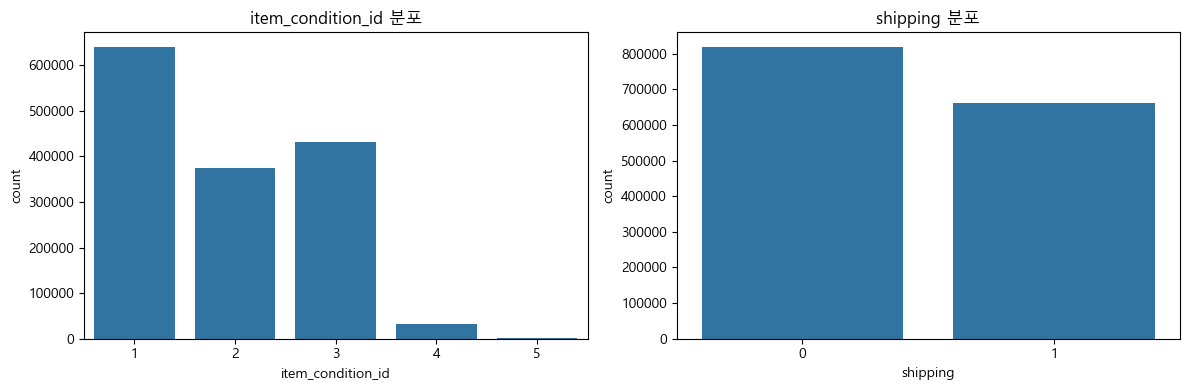

In [23]:
# item_condition_id, shipping 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='item_condition_id', data=mercari_df, ax=axes[0])
axes[0].set_title('item_condition_id 분포')
sns.countplot(x='shipping', data=mercari_df, ax=axes[1])
axes[1].set_title('shipping 분포')
plt.tight_layout()
plt.show()

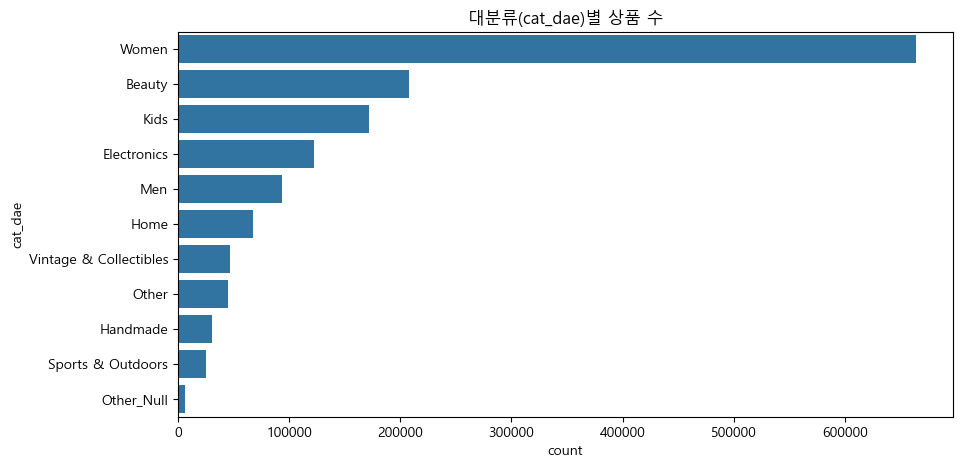

In [24]:
# 대분류(cat_dae)별 상품 수
plt.figure(figsize=(10, 5))
order = mercari_df['cat_dae'].value_counts().index
sns.countplot(y='cat_dae', data=mercari_df, order=order)
plt.title('대분류(cat_dae)별 상품 수')
plt.show()

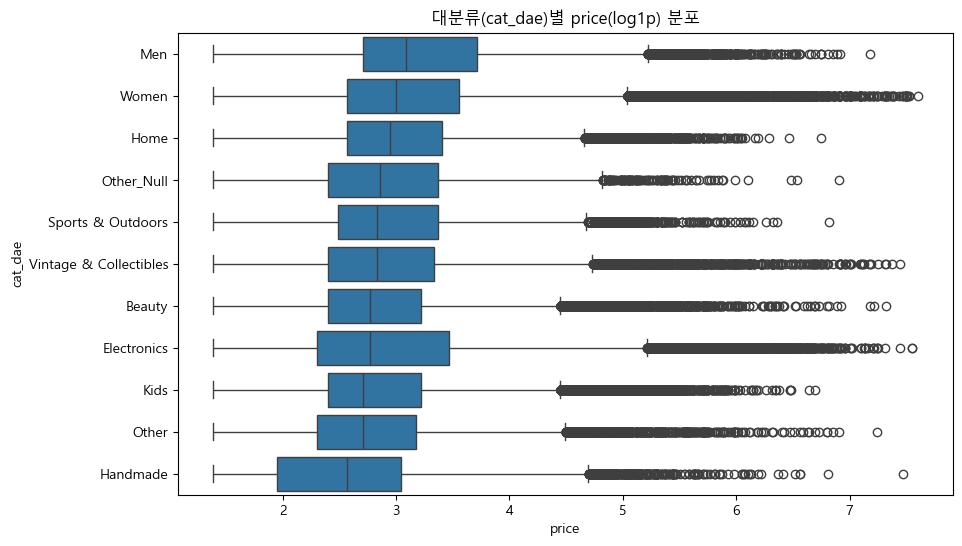

In [25]:
# 대분류(cat_dae)별 price(log1p) 분포
plt.figure(figsize=(10, 6))
order = mercari_df.groupby('cat_dae')['price'].median().sort_values(ascending=False).index
sns.boxplot(x='price', y='cat_dae', data=mercari_df, order=order)
plt.title('대분류(cat_dae)별 price(log1p) 분포')
plt.show()

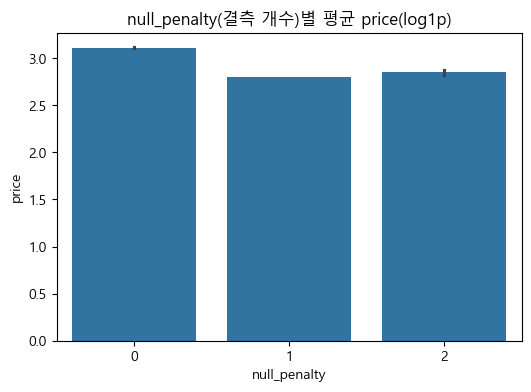

In [26]:
# null_penalty(결측 개수)별 평균 price(log1p) - Other_Null 페널티 피처가 실제로 가격과 관련 있는지 확인
plt.figure(figsize=(6, 4))
sns.barplot(x='null_penalty', y='price', data=mercari_df, estimator=np.mean)
plt.title('null_penalty(결측 개수)별 평균 price(log1p)')
plt.show()

## 11. 모델 학습 및 평가 (Ridge vs LightGBM)

`X_features`, `y_labels`를 가지고 `train_test_split`(80/20)을 `model_train_predict` 함수 안에서 수행하고,
Ridge와 LightGBM 두 모델의 RMSLE를 비교.

`y_labels`는 이미 `log1p(price)`이므로, 이 로그 스케일에서의 RMSE가 곧 원본 스케일의 RMSLE와 수학적으로 동일함.
(`np.expm1`로 원래 가격 스케일로 되돌렸다가 다시 `log1p`를 씌워 비교해도 항등변환이라 같은 값이 나오므로 별도 변환 불필요)

In [27]:
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

In [28]:
# y_labels가 이미 log1p(price)이므로, 이 스케일에서의 RMSE == 원본 스케일의 RMSLE
def rmsle(y_test, preds):
    return np.sqrt(mean_squared_error(y_test, preds))

In [29]:
def model_train_predict(model, X_features, y_labels):
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_labels, test_size=0.2, random_state=156
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return preds, y_test

In [30]:
# Ridge
linear_model = Ridge(solver='lsqr', fit_intercept=False, alpha=3)
linear_preds, linear_y_test = model_train_predict(linear_model, X_features, y_labels)
print('Ridge RMSLE:', rmsle(linear_y_test, linear_preds))

Ridge RMSLE: 0.47066665475516617


In [31]:
# LightGBM
lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=125, random_state=156)
lgbm_preds, lgbm_y_test = model_train_predict(lgbm_model, X_features, y_labels)
print('LightGBM RMSLE:', rmsle(lgbm_y_test, lgbm_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 206.831420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 577011


[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 37016
[LightGBM] [Info] Start training from score 2.980654


LightGBM RMSLE: 0.49220427574490655


In [32]:
# 비교
print(f'Ridge     RMSLE: {rmsle(linear_y_test, linear_preds):.5f}')
print(f'LightGBM  RMSLE: {rmsle(lgbm_y_test, lgbm_preds):.5f}')

Ridge     RMSLE: 0.47067
LightGBM  RMSLE: 0.49220


## 12. 가중치 기반 `combine_features` + Ridge 블렌딩

`category_name`(대/중/소분류) > `shipping` > `null_penalty`(Other_Null 개수) > 나머지(`name`, `item_description`, `brand_name`, `item_condition_id`) 순으로
우선순위를 두고, 우선순위가 높은 블록에 더 큰 가중치를 곱해 결합하는 `combine_features` 함수를 정의.

- Ridge는 L2 정규화가 모든 계수에 균일하게 걸리므로, 가중치를 키운 피처는 상대적으로 덜 억제되어 모델이 더 적극적으로 활용하게 됨.
- LightGBM은 트리 분기가 값의 크기가 아니라 순서/분포로 결정되어 이 가중치 방식의 영향을 거의 받지 않으므로, 이번 비교는 Ridge로만 진행.
- 원본 Ridge(11번 섹션의 `linear_model`/`linear_preds`)와 가중치 Ridge 모두 `train_test_split(random_state=156)`으로 나누므로 테스트셋 행이 동일 -> 두 예측값을 그대로 평균해서 블렌딩 가능.

In [33]:
def combine_features(weights=None):
    """
    category_name(cat_dae/jung/so) > shipping > null_penalty > 나머지(name, item_description, brand_name, item_condition_id)
    우선순위로 가중치를 곱해 sparse 피처 블록을 hstack으로 결합.
    """
    weights = weights or {'category': 3.0, 'shipping': 2.0, 'null_penalty': 2.0, 'default': 1.0}

    # NUM_COLS = ['item_condition_id', 'shipping', 'null_penalty'] 순서에 맞춰 컬럼별 가중치 적용
    num_weight_vec = np.array([weights['default'], weights['shipping'], weights['null_penalty']])
    X_num_weighted = csr_matrix(mercari_df[NUM_COLS].astype(float).values * num_weight_vec)

    return hstack([
        X_name * weights['default'],
        X_descp * weights['default'],
        X_cat['brand_name'] * weights['default'],
        X_cat['cat_dae'] * weights['category'],
        X_cat['cat_jung'] * weights['category'],
        X_cat['cat_so'] * weights['category'],
        X_num_weighted,
    ]).tocsr()

X_features_weighted = combine_features()
X_features_weighted.shape

(1481603, 55807)

In [34]:
# 가중치 적용 Ridge (원본 Ridge는 11번 섹션의 linear_model/linear_preds 재사용)
ridge_weighted = Ridge(solver='lsqr', fit_intercept=False, alpha=3)
weighted_preds, weighted_y_test = model_train_predict(ridge_weighted, X_features_weighted, y_labels)
print('Ridge(가중치) RMSLE:', rmsle(weighted_y_test, weighted_preds))

Ridge(가중치) RMSLE: 0.471539517010668


In [35]:
# 두 Ridge(원본/가중치) 예측 평균 블렌딩 - 동일 random_state=156 분할이라 테스트 행이 동일
blend_preds = (linear_preds + weighted_preds) / 2
print('Ridge Blend RMSLE:', rmsle(linear_y_test, blend_preds))

Ridge Blend RMSLE: 0.47083990353745175


In [36]:
# 가중치 효과 비교
print(f'Ridge(원본)   RMSLE: {rmsle(linear_y_test, linear_preds):.5f}')
print(f'Ridge(가중치) RMSLE: {rmsle(weighted_y_test, weighted_preds):.5f}')
print(f'Ridge Blend   RMSLE: {rmsle(linear_y_test, blend_preds):.5f}')

Ridge(원본)   RMSLE: 0.47067
Ridge(가중치) RMSLE: 0.47154
Ridge Blend   RMSLE: 0.47084


## 13. B안 - 단계적(잔차) LightGBM 파이프라인 + 전체 지표 비교

11~12번의 Ridge(원본/가중치/블렌딩)와 비교하기 위해, "우선순위 피처로 먼저 설명하고 남은 피처로 잔차를 보정"하는
B안을 LightGBM으로 구현.

1. **1단계**: `category_name`(cat_dae/jung/so) + `shipping` + `null_penalty`만으로 LGBM 학습 -> 1차 예측
2. **2단계**: 1단계의 잔차(`residual = y_train - 1차 예측`)를 타깃으로, `name`/`item_description`/`brand_name`/`item_condition_id`로 LGBM 학습
3. **최종 예측** = 1단계 예측 + 2단계 잔차 예측

11~12번과 동일하게 `random_state=156`으로 분할 -> 인덱스가 같아 모든 모델의 RMSLE를 동일한 테스트셋 기준으로 공정 비교 가능.

In [37]:
# 우선순위 피처(1단계): category_name(대/중/소분류) + shipping + null_penalty
X_priority = hstack([
    X_cat['cat_dae'], X_cat['cat_jung'], X_cat['cat_so'],
    X_num[:, [1, 2]],  # shipping, null_penalty
]).tocsr()

# 나머지 피처(2단계): name, item_description, brand_name, item_condition_id
X_rest = hstack([
    X_name, X_descp, X_cat['brand_name'], X_num[:, [0]],
]).tocsr()

print('X_priority:', X_priority.shape)
print('X_rest    :', X_rest.shape)

X_priority: (1481603, 998)
X_rest    : (1481603, 54809)


In [38]:
# 11~12번 Ridge와 동일한 random_state=156으로 분할 -> 테스트 인덱스가 동일해 공정 비교 가능
idx_train, idx_test = train_test_split(
    np.arange(X_features.shape[0]), test_size=0.2, random_state=156
)

y_arr = y_labels.to_numpy()
y_train_stage, y_test_stage = y_arr[idx_train], y_arr[idx_test]

In [39]:
# 1단계: 우선순위 피처만으로 LGBM 학습
stage1_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=63, random_state=156)
stage1_model.fit(X_priority[idx_train], y_train_stage)

stage1_train_pred = stage1_model.predict(X_priority[idx_train])
stage1_test_pred = stage1_model.predict(X_priority[idx_test])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1503
[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 751
[LightGBM] [Info] Start training from score 2.980654


In [40]:
# 2단계: 1단계 잔차를 나머지 피처로 보정
residual_train = y_train_stage - stage1_train_pred

stage2_model = LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=125, random_state=156)
stage2_model.fit(X_rest[idx_train], residual_train)

stage2_test_pred = stage2_model.predict(X_rest[idx_test])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 229.201078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 575508


[LightGBM] [Info] Number of data points in the train set: 1185282, number of used features: 36265
[LightGBM] [Info] Start training from score -0.000000


In [41]:
# 최종 예측 = 1단계 + 2단계(잔차) 예측
staged_preds = stage1_test_pred + stage2_test_pred
print('B안 단계적 LGBM RMSLE:', rmsle(y_test_stage, staged_preds))

B안 단계적 LGBM RMSLE: 0.49735273586097895


## 14. 전체 모델 지표 비교

In [42]:
print(f'Ridge(원본)        RMSLE: {rmsle(linear_y_test, linear_preds):.5f}')
print(f'Ridge(가중치)      RMSLE: {rmsle(weighted_y_test, weighted_preds):.5f}')
print(f'Ridge Blend        RMSLE: {rmsle(linear_y_test, blend_preds):.5f}')
print(f'LightGBM(단일)     RMSLE: {rmsle(lgbm_y_test, lgbm_preds):.5f}')
print(f'B안 단계적 LGBM    RMSLE: {rmsle(y_test_stage, staged_preds):.5f}')

Ridge(원본)        RMSLE: 0.47067
Ridge(가중치)      RMSLE: 0.47154
Ridge Blend        RMSLE: 0.47084
LightGBM(단일)     RMSLE: 0.49220
B안 단계적 LGBM    RMSLE: 0.49735
